In [1]:
!pip install torch-geometric


print("✓ PyTorch Geometric installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 15.8 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
✓ PyTorch Geometric installed!


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import torch_geometric
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.data import Data, Batch

print(f"PyTorch Geometric version: {torch_geometric.__version__}")

PyTorch Geometric version: 2.7.0


In [3]:
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=32, patch_size=2, in_channels=3, embed_dim=256):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2

        patch_dim = patch_size * patch_size * in_channels  # 2*2*3 = 12
        self.projection = nn.Linear(patch_dim, embed_dim)

    def forward(self, x):
        batch_size = x.shape[0]
        x = x.unfold(2, self.patch_size, self.patch_size)  # (batch, 3, 16, 32, 2)
        x = x.unfold(3, self.patch_size, self.patch_size)  # (batch, 3, 16, 16, 2, 2)
        x = x.contiguous().view(batch_size, -1, self.patch_size * self.patch_size * 3)
        # Step 3: Project to embedding dimension
        x = self.projection(x)  # (batch, 256, 256)
        return x

In [4]:
patch_embed = PatchEmbedding()
dummy_img = torch.randn(2, 3, 32, 32)
output = patch_embed(dummy_img)
print(f"Output shape: {output.shape}")
print(f"Number of patches: {patch_embed.num_patches}")

Output shape: torch.Size([2, 256, 256])
Number of patches: 256


Created adjacency matrix for 8×8 grid:
  - Total nodes (patches): 64
  - Total edges: 224
  - Avg degree: 3.50


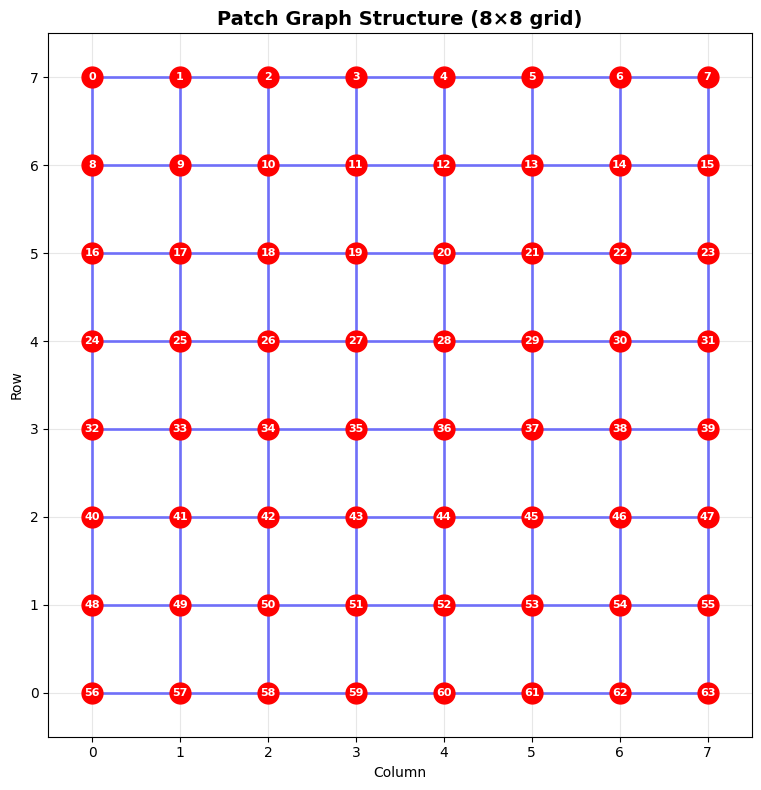

In [5]:
def create_adjacency_matrix(num_patches_per_side):
    n = num_patches_per_side
    total_patches = n * n
    edges = []
    for i in range(n):
        for j in range(n):
            current_idx = i * n + j

            if j < n - 1:
                right_idx = i * n + (j + 1)
                edges.append([current_idx, right_idx])
                edges.append([right_idx, current_idx])
            if i < n - 1:
                bottom_idx = (i + 1) * n + j
                edges.append([current_idx, bottom_idx])
                edges.append([bottom_idx, current_idx])

    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

    print(f"Created adjacency matrix for {n}×{n} grid:")
    print(f"  - Total nodes (patches): {total_patches}")
    print(f"  - Total edges: {edge_index.shape[1]}")
    print(f"  - Avg degree: {edge_index.shape[1] / total_patches:.2f}")

    return edge_index


patch_size = 4
img_size = 32
num_patches_per_side = img_size // patch_size  # 8
edge_index = create_adjacency_matrix(num_patches_per_side)
def visualize_patch_graph(num_patches_per_side, edge_index):
    n = num_patches_per_side
    fig, ax = plt.subplots(figsize=(8, 8))
    positions = {}
    for i in range(n):
        for j in range(n):
            node_idx = i * n + j
            positions[node_idx] = (j, n - 1 - i)
    for k in range(edge_index.shape[1]):
        src, dst = edge_index[0, k].item(), edge_index[1, k].item()
        x = [positions[src][0], positions[dst][0]]
        y = [positions[src][1], positions[dst][1]]
        ax.plot(x, y, 'b-', alpha=0.3, linewidth=2)
    for node_idx, (x, y) in positions.items():
        ax.plot(x, y, 'ro', markersize=15)
        ax.text(x, y, str(node_idx), ha='center', va='center',
                fontsize=8, color='white', fontweight='bold')
    ax.set_xlim(-0.5, n - 0.5)
    ax.set_ylim(-0.5, n - 0.5)
    ax.set_aspect('equal')
    ax.set_title(f'Patch Graph Structure ({n}×{n} grid)', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('Column')
    ax.set_ylabel('Row')
    plt.tight_layout()
    plt.show()

visualize_patch_graph(num_patches_per_side, edge_index)

In [6]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),  # Data augmentation
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize to [-1, 1]
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

100%|███████████████████████████████████████████████████████████████████████| 170M/170M [01:09<00:00, 2.46MB/s]


Training samples: 50000
Test samples: 10000


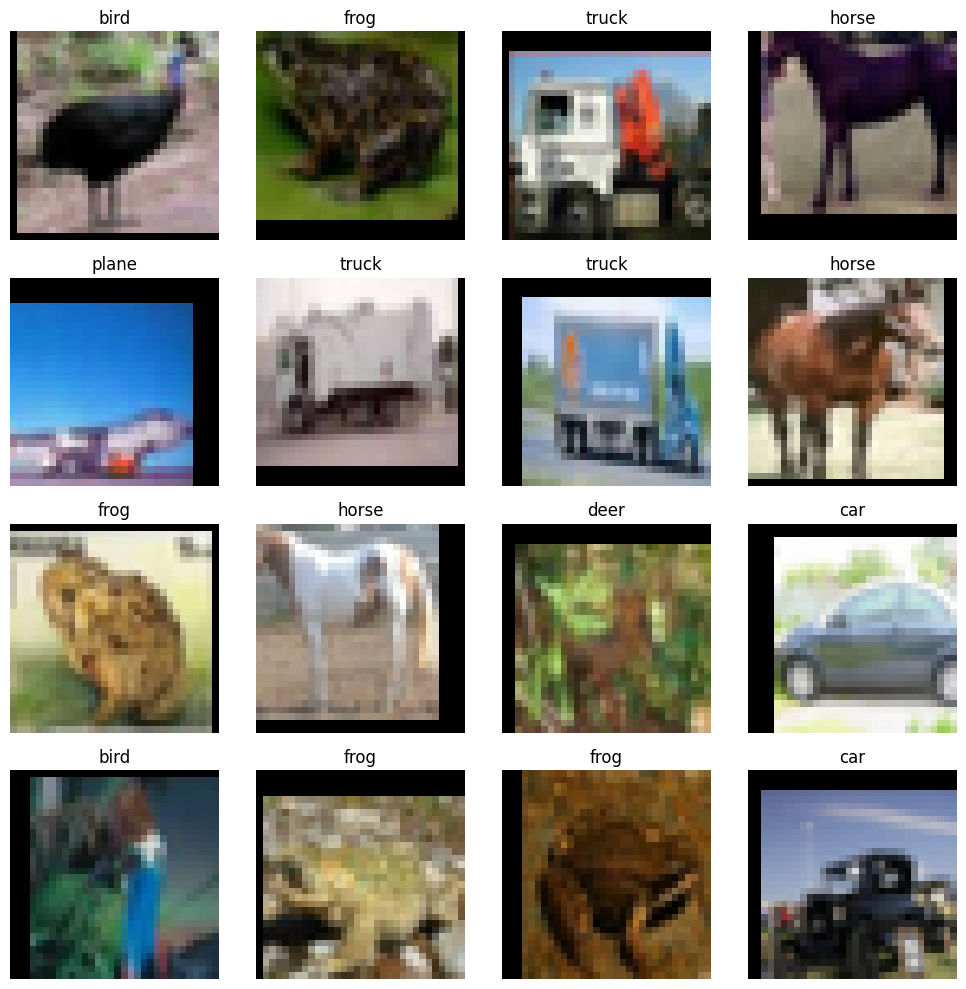

In [7]:
import matplotlib.pyplot as plt
import numpy as np

classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

def show_images(dataset, n=16):
    fig, axes = plt.subplots(4, 4, figsize=(10, 10))

    for i, ax in enumerate(axes.flat):
        idx = np.random.randint(len(dataset))
        img, label = dataset[idx]
        img = img * 0.5 + 0.5
        img = img.numpy().transpose(1, 2, 0)
        ax.imshow(img)
        ax.set_title(f"{classes[label]}")
        ax.axis('off')

    plt.tight_layout()
    plt.show()

show_images(train_dataset)

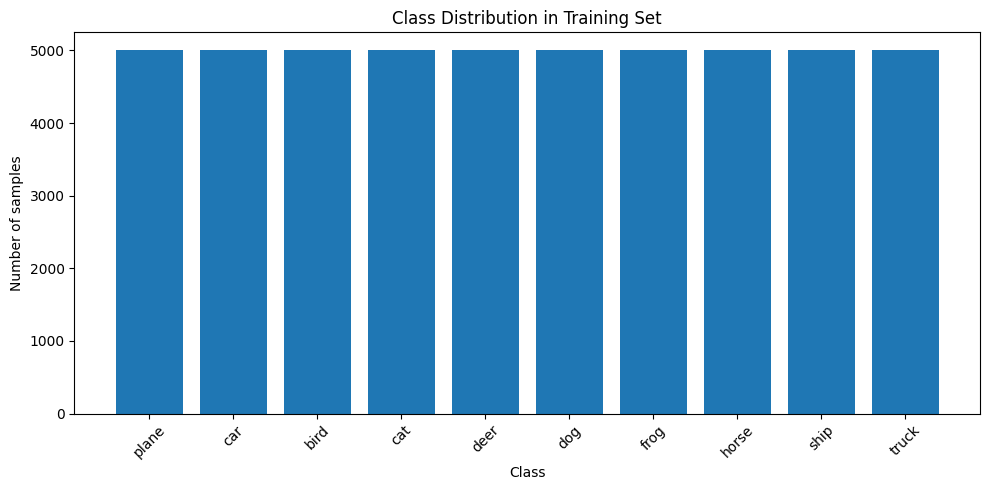


Class distribution:
plane: 5000 samples
car: 5000 samples
bird: 5000 samples
cat: 5000 samples
deer: 5000 samples
dog: 5000 samples
frog: 5000 samples
horse: 5000 samples
ship: 5000 samples
truck: 5000 samples


In [8]:
from collections import Counter

train_labels = [label for _, label in train_dataset]
label_counts = Counter(train_labels)

plt.figure(figsize=(10, 5))
plt.bar(range(len(classes)), [label_counts[i] for i in range(len(classes))])
plt.xticks(range(len(classes)), classes, rotation=45)
plt.xlabel('Class')
plt.ylabel('Number of samples')
plt.title('Class Distribution in Training Set')
plt.tight_layout()
plt.show()

print("\nClass distribution:")
for i, class_name in enumerate(classes):
    print(f"{class_name}: {label_counts[i]} samples")

In [9]:
dataiter = iter(train_loader)
images, labels = next(dataiter)

print(f"\nBatch statistics:")
print(f"Batch shape: {images.shape}")
print(f"Min pixel value: {images.min():.3f}")
print(f"Max pixel value: {images.max():.3f}")
print(f"Mean pixel value: {images.mean():.3f}")
print(f"Std pixel value: {images.std():.3f}")


Batch statistics:
Batch shape: torch.Size([128, 3, 32, 32])
Min pixel value: -1.000
Max pixel value: 1.000
Mean pixel value: -0.206
Std pixel value: 0.559


Visualizing patches for: truck


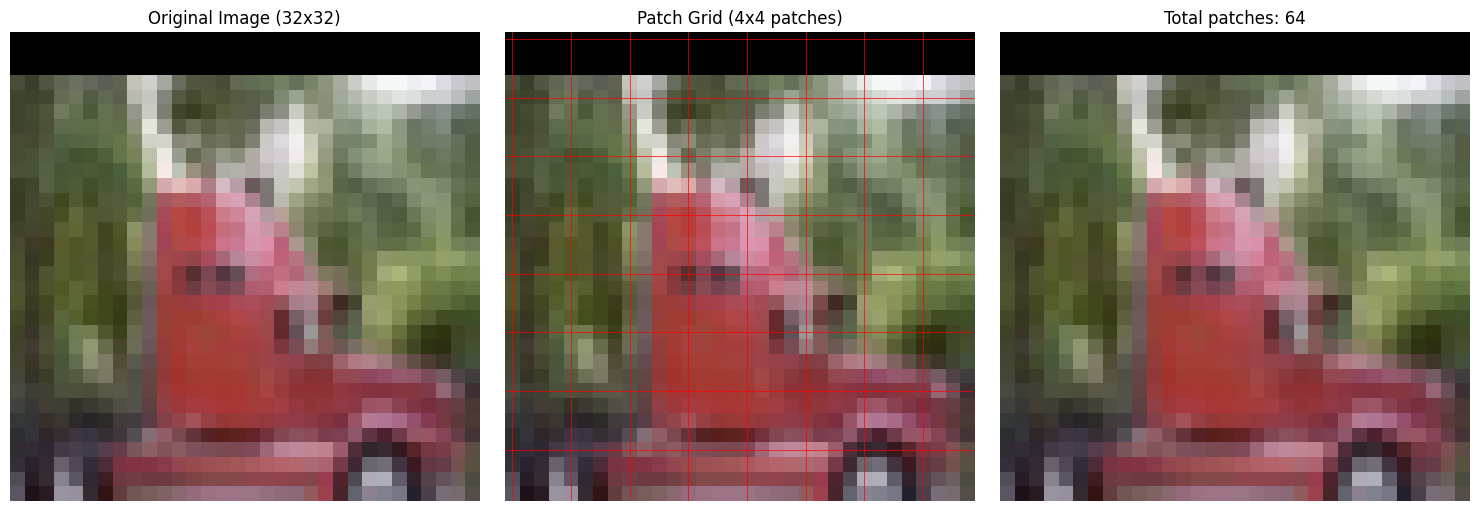

In [10]:
def visualize_patches(image, patch_size=4):
    img = image * 0.5 + 0.5
    img = img.numpy().transpose(1, 2, 0)
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img)
    axes[0].set_title('Original Image (32x32)')
    axes[0].axis('off')
    axes[1].imshow(img)
    for i in range(0, 32, patch_size):
        axes[1].axhline(i, color='red', linewidth=0.5)
        axes[1].axvline(i, color='red', linewidth=0.5)
    axes[1].set_title(f'Patch Grid ({patch_size}x{patch_size} patches)')
    axes[1].axis('off')
    num_patches_per_side = 32 // patch_size
    patch_grid = np.zeros((32, 32, 3))

    for i in range(num_patches_per_side):
        for j in range(num_patches_per_side):
            patch = img[i*patch_size:(i+1)*patch_size,
                       j*patch_size:(j+1)*patch_size]
            patch_grid[i*patch_size:(i+1)*patch_size,
                      j*patch_size:(j+1)*patch_size] = patch

    axes[2].imshow(patch_grid)
    axes[2].set_title(f'Total patches: {num_patches_per_side**2}')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

img, label = train_dataset[np.random.randint(len(train_dataset))]
print(f"Visualizing patches for: {classes[label]}")
visualize_patches(img, patch_size=4)

In [18]:
class PatchGNN(nn.Module):
    def __init__(self, 
                 img_size=32,
                 patch_size=4,
                 in_channels=3,
                 num_classes=10,
                 embed_dim=256,
                 hidden_dim=512,
                 num_gnn_layers=6,
                 dropout=0.1):
        super().__init__()
        
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches_per_side = img_size // patch_size
        self.num_patches = self.num_patches_per_side ** 2
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        self.edge_index = self.create_adjacency_with_self_loops(self.num_patches_per_side)
        from torch_geometric.nn import SAGEConv
        self.gnn_layers = nn.ModuleList()
        self.norms = nn.ModuleList()
        for i in range(num_gnn_layers):
            in_dim = embed_dim if i == 0 else hidden_dim
            self.gnn_layers.append(SAGEConv(in_dim, hidden_dim))
            self.norms.append(nn.BatchNorm1d(hidden_dim))  # BatchNorm instead of LayerNorm
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, num_classes)
        )
        print(f"\n{'='*60}")
        print(f"Improved PatchGNN Architecture")
        print(f"{'='*60}")
        print(f"Patches: {self.num_patches} ({self.num_patches_per_side}×{self.num_patches_per_side})")
        print(f"Embedding dim: {embed_dim} → Hidden dim: {hidden_dim}")
        print(f"GNN layers: {num_gnn_layers} (SAGEConv)")
        print(f"Edges: {self.edge_index.shape[1]} (with self-loops)")
        print(f"{'='*60}\n")
    
    def create_adjacency_with_self_loops(self, num_patches_per_side):
        n = num_patches_per_side
        edges = []
        for i in range(n):
            for j in range(n):
                current_idx = i * n + j
                edges.append([current_idx, current_idx])
                if j < n - 1:
                    right_idx = i * n + (j + 1)
                    edges.append([current_idx, right_idx])
                    edges.append([right_idx, current_idx])
                if i < n - 1:
                    bottom_idx = (i + 1) * n + j
                    edges.append([current_idx, bottom_idx])
                    edges.append([bottom_idx, current_idx])
        
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
        return edge_index
    
    def forward(self, x):
        batch_size = x.shape[0]
        node_features = self.patch_embed(x)
        graph_list = []
        edge_index = self.edge_index.to(x.device)
        for b in range(batch_size):
            graph = Data(x=node_features[b], edge_index=edge_index)
            graph_list.append(graph)
        
        batched_graph = Batch.from_data_list(graph_list)
        x = batched_graph.x
        edge_index = batched_graph.edge_index
        batch = batched_graph.batch
        
        for i, (gnn, norm) in enumerate(zip(self.gnn_layers, self.norms)):
            identity = x
            x = gnn(x, edge_index)
            x = norm(x)
            x = F.relu(x)
            x = self.dropout(x)
            if i > 0:
                x = x + identity
        
        x = global_mean_pool(x, batch)
        logits = self.classifier(x)
        
        return logits

model = PatchGNN(
    img_size=32,
    patch_size=4,
    in_channels=3,
    num_classes=10,
    embed_dim=256,
    hidden_dim=256,
    num_gnn_layers=4,
    dropout=0.1
)
dummy_input = torch.randn(4, 3, 32, 32)
output = model(dummy_input)
print(f"\nTest forward pass:")
print(f"  Input shape: {dummy_input.shape}")
print(f"  Output shape: {output.shape}")
print(f"  Total parameters: {sum(p.numel() for p in model.parameters()):,}")


Improved PatchGNN Architecture
Patches: 64 (8×8)
Embedding dim: 256 → Hidden dim: 256
GNN layers: 4 (SAGEConv)
Edges: 288 (with self-loops)


Test forward pass:
  Input shape: torch.Size([4, 3, 32, 32])
  Output shape: torch.Size([4, 10])
  Total parameters: 640,650


In [19]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    pbar = tqdm(train_loader, desc='Training')

    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        pbar.set_postfix({
            'loss': f'{running_loss/len(pbar):.3f}',
            'acc': f'{100.*correct/total:.2f}%'
        })

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total

    return epoch_loss, epoch_acc

In [20]:
def train_model(model, train_loader, test_loader, criterion, optimizer, scheduler,
                num_epochs=50, device='cuda'):
    train_losses, train_accs = [], []
    test_losses, test_accs = [], []
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        test_loss, test_acc = evaluate(model, test_loader, criterion, device)
        test_losses.append(test_loss)
        test_accs.append(test_acc)
        scheduler.step()
        print(f"\nTrain Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")
        print(f"Learning Rate: {scheduler.get_last_lr()[0]:.6f}")
        if test_acc > best_acc:
            best_acc = test_acc
            torch.save(model.state_dict(), 'best_mlp_mixer.pth')
            print(f"✓ New best model saved! (Test Acc: {best_acc:.2f}%)")

    return train_losses, train_accs, test_losses, test_accs

In [21]:
def evaluate(model, test_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    pbar = tqdm(test_loader, desc='Evaluating')

    with torch.no_grad():
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            pbar.set_postfix({
                'loss': f'{running_loss/len(pbar):.3f}',
                'acc': f'{100.*correct/total:.2f}%'
            })

    epoch_loss = running_loss / len(test_loader)
    epoch_acc = 100. * correct / total

    return epoch_loss, epoch_acc

In [22]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}\n")
model = PatchGNN(
    img_size=32,
    patch_size=4,
    in_channels=3,
    num_classes=10,
    embed_dim=256,
    hidden_dim=512,
    num_gnn_layers=6,
    dropout=0.1
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=75)

print(f"Model has {sum(p.numel() for p in model.parameters()):,} parameters\n")
print("Starting training \n")

train_losses, train_accs, test_losses, test_accs = train_model(
    model, train_loader, test_loader, criterion, optimizer, scheduler,
    num_epochs=35, device=device
)



Using device: cuda


Improved PatchGNN Architecture
Patches: 64 (8×8)
Embedding dim: 256 → Hidden dim: 512
GNN layers: 6 (SAGEConv)
Edges: 288 (with self-loops)

Model has 3,303,434 parameters

Starting training 


Epoch 1/35


Evaluating: 100%|██████████████████████████████████████| 79/79 [00:03<00:00, 24.89it/s, loss=1.949, acc=30.95%]



Train Loss: 1.8957 | Train Acc: 29.27%
Test Loss: 1.9488 | Test Acc: 30.95%
Learning Rate: 0.001000
✓ New best model saved! (Test Acc: 30.95%)

Epoch 2/35


Evaluating: 100%|██████████████████████████████████████| 79/79 [00:03<00:00, 24.84it/s, loss=1.628, acc=42.77%]



Train Loss: 1.6123 | Train Acc: 40.78%
Test Loss: 1.6285 | Test Acc: 42.77%
Learning Rate: 0.000998
✓ New best model saved! (Test Acc: 42.77%)

Epoch 3/35


...


Train Loss: 0.7159 | Train Acc: 74.64%
Test Loss: 0.9184 | Test Acc: 68.01%
Learning Rate: 0.000594
✓ New best model saved! (Test Acc: 68.01%)

Epoch 34/35


Evaluating: 100%|██████████████████████████████████████| 79/79 [00:03<00:00, 23.60it/s, loss=1.002, acc=65.94%]



Train Loss: 0.7011 | Train Acc: 74.97%
Test Loss: 1.0016 | Test Acc: 65.94%
Learning Rate: 0.000573

Epoch 35/35


Evaluating: 100%|██████████████████████████████████████| 79/79 [00:03<00:00, 24.44it/s, loss=0.917, acc=68.52%]



Train Loss: 0.6935 | Train Acc: 75.41%
Test Loss: 0.9165 | Test Acc: 68.52%
Learning Rate: 0.000552
✓ New best model saved! (Test Acc: 68.52%)


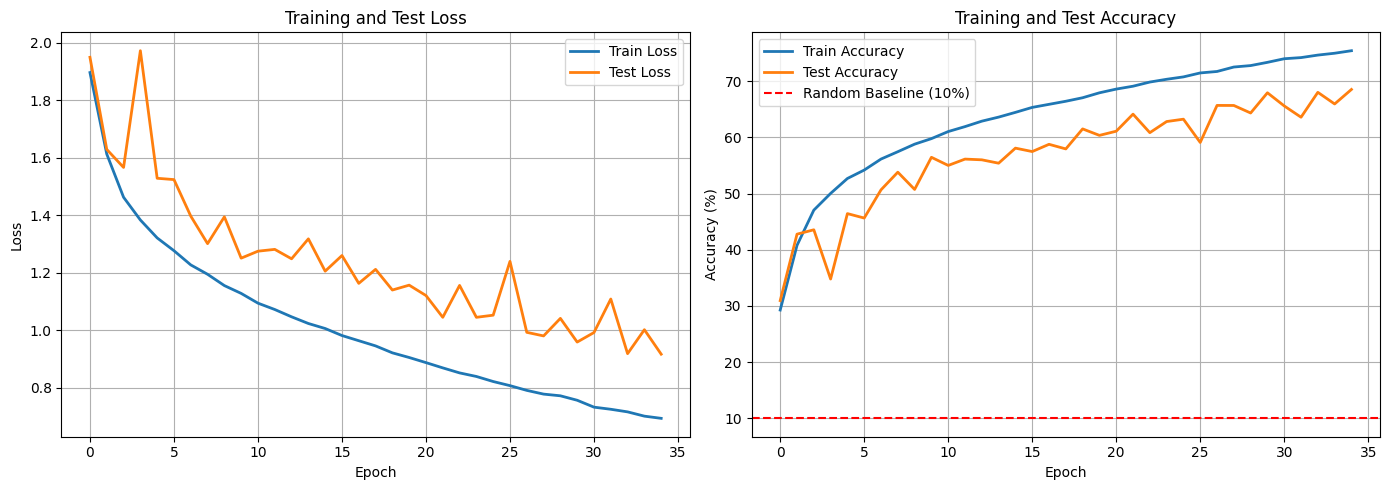


Final Results:
Best Test Accuracy: 68.52%
Final Train Accuracy: 75.41%
Final Test Accuracy: 68.52%


In [23]:
def plot_training_history(train_losses, train_accs, test_losses, test_accs):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(train_losses, label='Train Loss', linewidth=2)
    ax1.plot(test_losses, label='Test Loss', linewidth=2)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training and Test Loss')
    ax1.legend()
    ax1.grid(True)
    ax2.plot(train_accs, label='Train Accuracy', linewidth=2)
    ax2.plot(test_accs, label='Test Accuracy', linewidth=2)
    ax2.axhline(y=10, color='r', linestyle='--', label='Random Baseline (10%)')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('Training and Test Accuracy')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

    print(f"\nFinal Results:")
    print(f"Best Test Accuracy: {max(test_accs):.2f}%")
    print(f"Final Train Accuracy: {train_accs[-1]:.2f}%")
    print(f"Final Test Accuracy: {test_accs[-1]:.2f}%")

plot_training_history(train_losses, train_accs, test_losses, test_accs)

Evaluating: 100%|██████████████████████████████████████████████████████████████| 79/79 [00:03<00:00, 25.30it/s]


              precision    recall  f1-score   support

       plane     0.6528    0.7350    0.6914      1000
         car     0.8710    0.7560    0.8094      1000
        bird     0.5978    0.5930    0.5954      1000
         cat     0.5740    0.4460    0.5020      1000
        deer     0.6368    0.5980    0.6168      1000
         dog     0.6183    0.6220    0.6201      1000
        frog     0.7595    0.7010    0.7291      1000
       horse     0.6837    0.8040    0.7390      1000
        ship     0.6371    0.9040    0.7474      1000
       truck     0.8953    0.6930    0.7813      1000

    accuracy                         0.6852     10000
   macro avg     0.6926    0.6852    0.6832     10000
weighted avg     0.6926    0.6852    0.6832     10000

plane     :  73.50% (735/1000)
car       :  75.60% (756/1000)
bird      :  59.30% (593/1000)
cat       :  44.60% (446/1000)
deer      :  59.80% (598/1000)
dog       :  62.20% (622/1000)
frog      :  70.10% (701/1000)
horse     :  80.40% (804

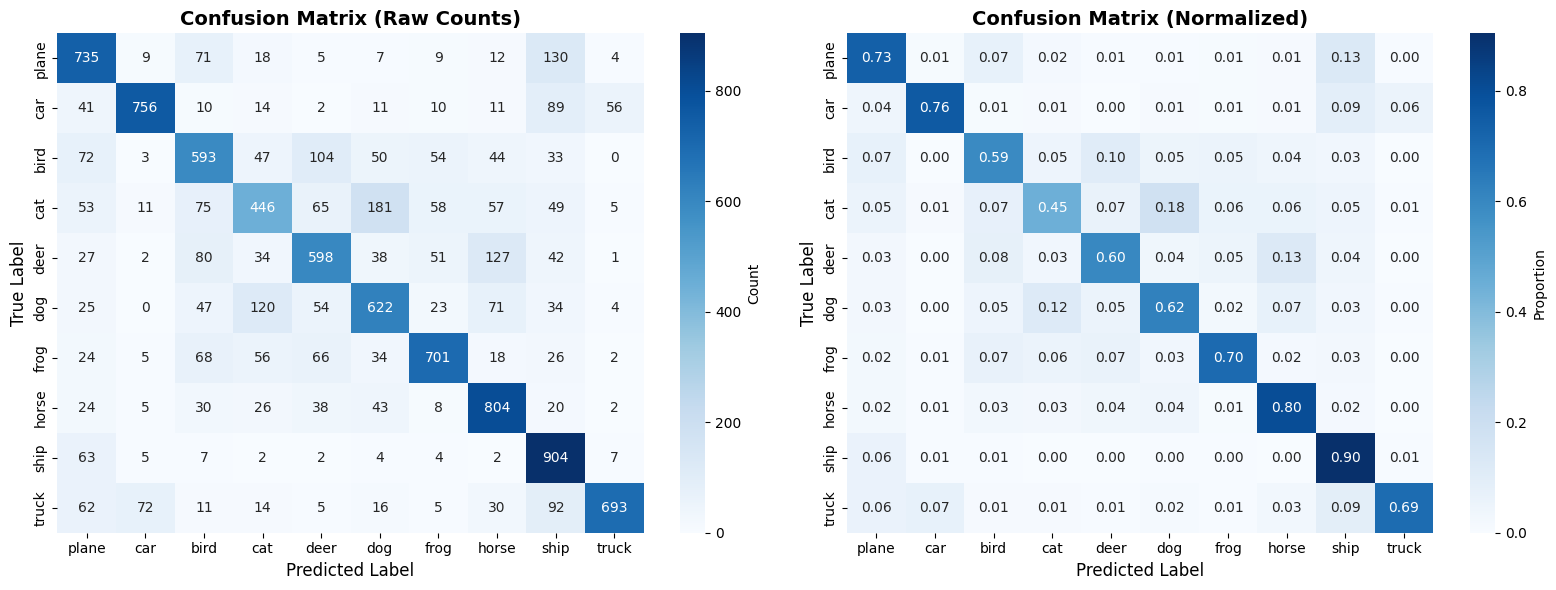



Count    True Class   Predicted As


181      cat          dog         
130      plane        ship        
127      deer         horse       
120      dog          cat         
104      bird         deer        
92       truck        ship        
89       car          ship        
80       deer         bird        
75       cat          bird        
72       truck        car         


In [24]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

model.load_state_dict(torch.load('best_mlp_mixer.pth'))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Evaluating'):
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
print(classification_report(all_labels, all_preds, target_names=classes, digits=4))

class_correct = np.zeros(10)
class_total = np.zeros(10)
for label, pred in zip(all_labels, all_preds):
    class_total[label] += 1
    if label == pred:
        class_correct[label] += 1

for i, class_name in enumerate(classes):
    accuracy = 100 * class_correct[i] / class_total[i]
    print(f"{class_name:10s}: {accuracy:6.2f}% ({int(class_correct[i])}/{int(class_total[i])})")
overall_acc = 100 * class_correct.sum() / class_total.sum()
print(f"{'Overall':10s}: {overall_acc:6.2f}%")
best_idx = np.argmax(class_correct / class_total)
worst_idx = np.argmin(class_correct / class_total)
print("\n")
print(f"\n✓ Best:  {classes[best_idx]} ({100*class_correct[best_idx]/class_total[best_idx]:.2f}%)")
print(f"✗ Worst: {classes[worst_idx]} ({100*class_correct[worst_idx]/class_total[worst_idx]:.2f}%)")
print("\n")
cm = confusion_matrix(all_labels, all_preds)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes, ax=ax1,
            cbar_kws={'label': 'Count'})
ax1.set_xlabel('Predicted Label', fontsize=12)
ax1.set_ylabel('True Label', fontsize=12)
ax1.set_title('Confusion Matrix (Raw Counts)', fontsize=14, fontweight='bold')

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=classes, yticklabels=classes, ax=ax2,
            cbar_kws={'label': 'Proportion'})
ax2.set_xlabel('Predicted Label', fontsize=12)
ax2.set_ylabel('True Label', fontsize=12)
ax2.set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n")
mistakes = []
for i in range(10):
    for j in range(10):
        if i != j:
            mistakes.append((cm[i, j], classes[i], classes[j]))
mistakes.sort(reverse=True)
print(f"{'Count':<8} {'True Class':<12} {'Predicted As':<12}")
print("\n")
for count, true_class, pred_class in mistakes[:10]:
    print(f"{int(count):<8} {true_class:<12} {pred_class:<12}")

